# 02 — Station Clustering & Segmentation
**Citi Bike Demand Forecasting & A/B Testing Framework**

Goals:
1. Build per-station feature matrix from hourly demand
2. K-means → commuter / tourist / recreational / low-activity segments
3. DBSCAN → geospatial density clusters
4. Folium map with cluster overlays
5. Save cluster assignments → used as A/B randomization units in Phase 5

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from pathlib import Path

from src.models.clustering import (
    build_station_features,
    kmeans_elbow,
    fit_kmeans,
    fit_dbscan,
    CLUSTER_NAMES,
)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Processed Data

In [2]:
hourly = pd.read_parquet(PROCESSED_DIR / 'hourly_demand_2024Q1.parquet')
station_summary = pd.read_parquet(PROCESSED_DIR / 'station_summary_2024Q1.parquet')

print(f'Hourly demand rows:  {len(hourly):,}')
print(f'Unique stations:     {hourly["station_id"].nunique():,}')
print(f'Station summary:     {len(station_summary):,} stations')
hourly.head(3)

Hourly demand rows:  1,963,864
Unique stations:     2,269
Station summary:     2,269 stations


,station_id,hour,trip_count,member_trips,casual_trips,classic_trips,electric_trips,lat,lng,hour_of_day,day_of_week,month,is_weekend
0,190 Morgan,2024-02-23 12:00:00,1,1,0,0,1,40.711072,-73.932096,12,4,2,0
1,2733.03,2024-01-01 14:00:00,3,0,3,0,3,40.633385,-74.016562,14,0,1,0
2,2733.03,2024-01-01 16:00:00,5,5,0,1,4,40.633385,-74.016562,16,0,1,0


## 2. Feature Engineering

In [3]:
features = build_station_features(hourly)
print(f'Feature matrix: {features.shape}  ({features.shape[0]} stations × {features.shape[1]} features)')
features.head(3)

Feature matrix: (2269, 30)  (2269 stations × 30 features)


,h00,h01,h02,h03,h04,h05,h06,h07,h08,h09,...,h20,h21,h22,h23,am_peak,pm_peak,wkday_wkend_ratio,log_demand,lat,lng
station_id,,,,,,,,,,,,,,,,,,,,,
190 Morgan,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.693147,40.711072,-73.932096
2733.03,0.034246,0.00000,0.034246,0.0,0.0,0.034246,0.102738,0.034246,0.042029,0.051369,...,0.039138,0.053271,0.089039,0.068492,1.021152,0.912458,0.915663,5.659482,40.633385,-74.016562
2782.02,0.049169,0.13385,0.000000,0.0,0.0,0.000000,0.000000,0.038243,0.047804,0.053990,...,0.038243,0.043023,0.057364,0.041185,1.120291,1.261555,0.886266,5.981414,40.635679,-74.020005


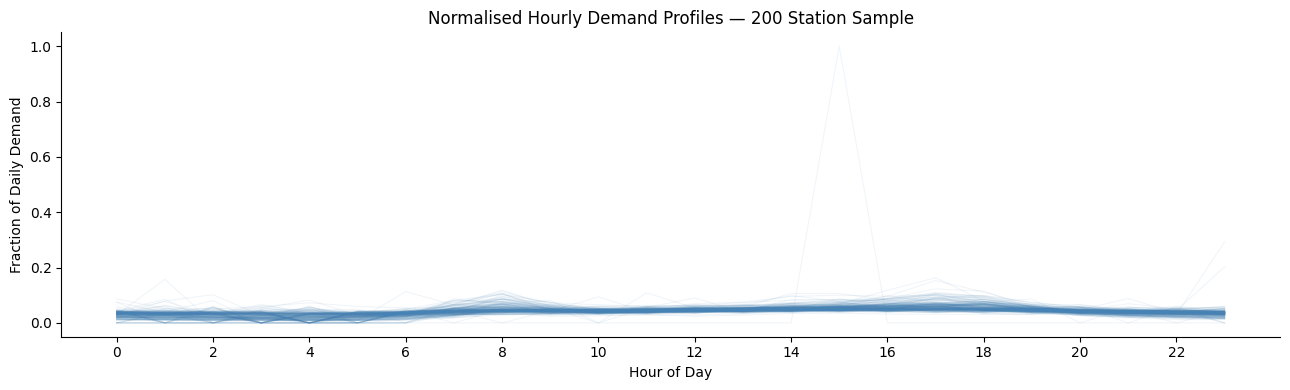

In [4]:
# Visualise what the normalised demand profiles look like for a sample of stations
profile_cols = [c for c in features.columns if c.startswith('h')]
sample = features[profile_cols].sample(200, random_state=42)

fig, ax = plt.subplots(figsize=(13, 4))
for _, row in sample.iterrows():
    ax.plot(range(24), row.values, alpha=0.08, color='steelblue', linewidth=0.8)
ax.set_title('Normalised Hourly Demand Profiles — 200 Station Sample')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraction of Daily Demand')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## 3. K-Means — Choose K

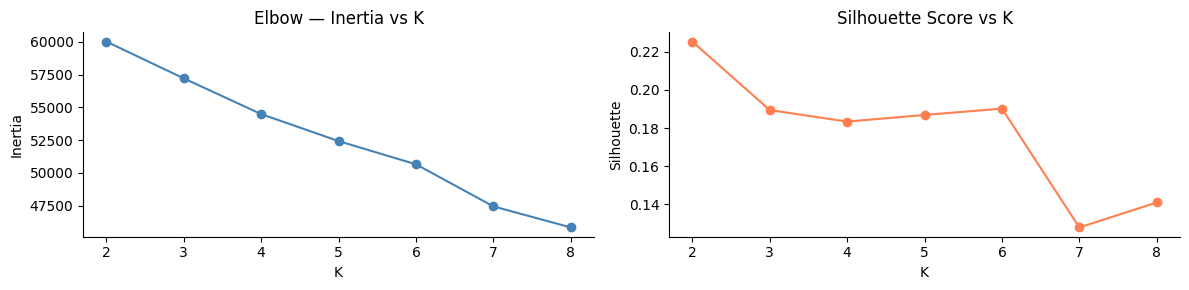

In [5]:
k_vals, inertias, silhouettes = kmeans_elbow(features, k_range=range(2, 9))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(k_vals, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow — Inertia vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_vals, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

## 4. K-Means — Final Model (K=4)

In [6]:
K = 4
labels, scaler, km_model = fit_kmeans(features, n_clusters=K)

features['kmeans_cluster'] = labels
print('Cluster sizes:')
print(features['kmeans_cluster'].value_counts().sort_index())

Cluster sizes:
kmeans_cluster
0    1330
1     120
2       3
3     816
Name: count, dtype: int64


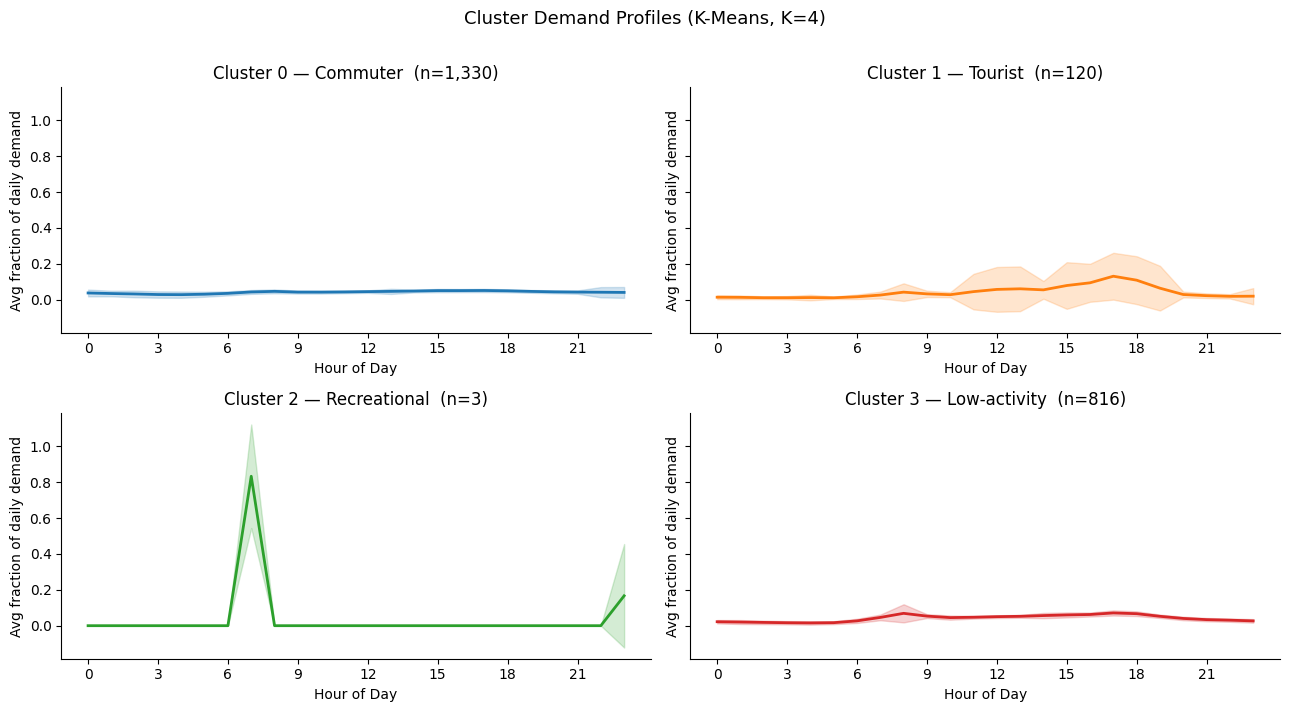

In [7]:
# Profile of each cluster — avg normalised demand curve
profile_cols = [c for c in features.columns if c.startswith('h')]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
axes = axes.flatten()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for k in range(K):
    grp = features[features['kmeans_cluster'] == k][profile_cols]
    mean_profile = grp.mean()
    std_profile = grp.std()
    ax = axes[k]
    ax.plot(range(24), mean_profile.values, color=colors[k], linewidth=2)
    ax.fill_between(
        range(24),
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.2, color=colors[k]
    )
    ax.set_title(f'Cluster {k} — {CLUSTER_NAMES.get(k, "")}  (n={len(grp):,})')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg fraction of daily demand')
    ax.set_xticks(range(0, 24, 3))

plt.suptitle('Cluster Demand Profiles (K-Means, K=4)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Cluster summary stats
summary_cols = ['am_peak', 'pm_peak', 'wkday_wkend_ratio', 'log_demand']
cluster_summary = (
    features.groupby('kmeans_cluster')[summary_cols]
    .mean()
    .round(3)
)
cluster_summary.index = [f'{i} — {CLUSTER_NAMES.get(i, "")}' for i in cluster_summary.index]
print(cluster_summary.to_string())

                  am_peak  pm_peak  wkday_wkend_ratio  log_demand
0 — Commuter        1.056    1.176              1.000       6.449
1 — Tourist         0.803    2.431              1.673       7.447
2 — Recreational    6.667    0.000              1.000       0.828
3 — Low-activity    1.347    1.522              1.090       8.250


In [9]:
# Rename clusters based on profile inspection
# Adjust CLUSTER_NAMES in clustering.py if labels don't match after running
features['cluster_name'] = features['kmeans_cluster'].map(CLUSTER_NAMES)

## 5. DBSCAN — Geospatial Density

In [10]:
db_labels = fit_dbscan(features, eps=0.006, min_samples=5)
features['dbscan_cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f'DBSCAN: {n_clusters} geographic clusters, {n_noise} noise stations')
print(pd.Series(db_labels).value_counts().head(10))

DBSCAN: 3 geographic clusters, 27 noise stations
 0    1188
 1    1047
-1      27
 2       7
Name: count, dtype: int64


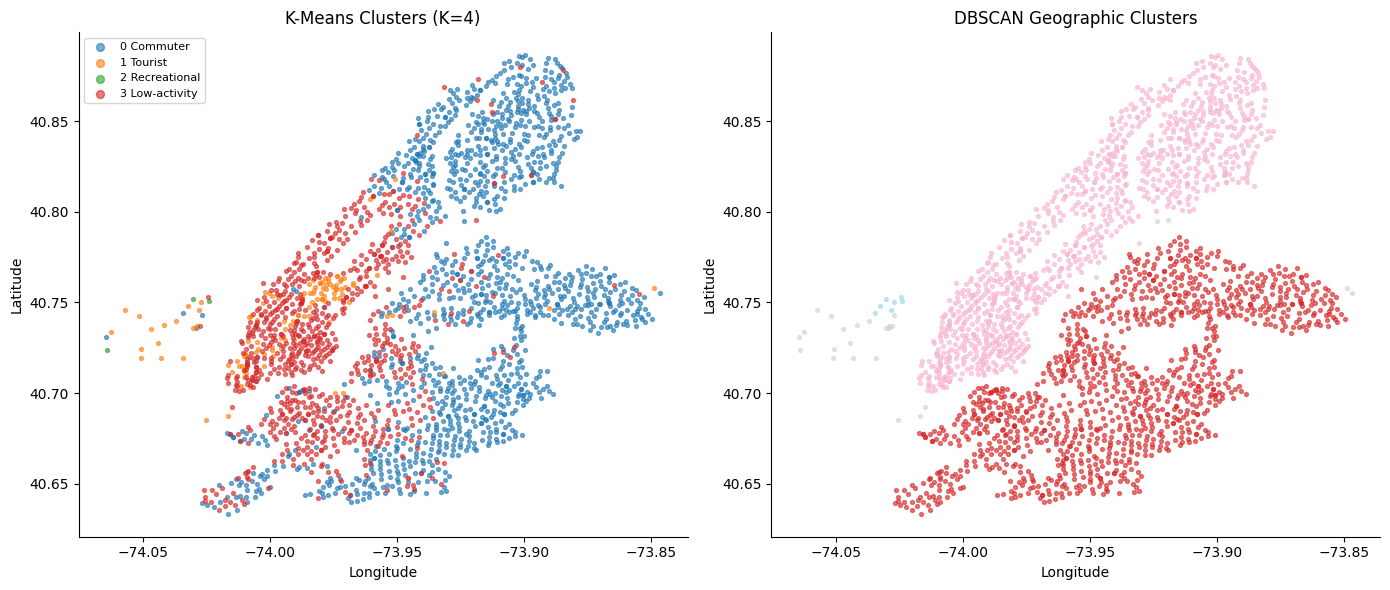

In [11]:
# Geographic scatter — K-means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for k in range(K):
    mask = features['kmeans_cluster'] == k
    axes[0].scatter(
        features.loc[mask, 'lng'], features.loc[mask, 'lat'],
        s=8, alpha=0.6, label=f'{k} {CLUSTER_NAMES.get(k, "")}', color=colors[k]
    )
axes[0].set_title('K-Means Clusters (K=4)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(markerscale=2, fontsize=8)

db_unique = sorted(set(db_labels))
cmap = plt.cm.get_cmap('tab20', len(db_unique))
for i, cluster_id in enumerate(db_unique):
    mask = features['dbscan_cluster'] == cluster_id
    label = 'Noise' if cluster_id == -1 else f'Zone {cluster_id}'
    color = 'lightgray' if cluster_id == -1 else cmap(i)
    axes[1].scatter(
        features.loc[mask, 'lng'], features.loc[mask, 'lat'],
        s=8, alpha=0.6, label=label, color=color
    )
axes[1].set_title('DBSCAN Geographic Clusters')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 6. Folium Interactive Map

In [12]:
CLUSTER_COLORS = {
    0: 'blue',
    1: 'red',
    2: 'green',
    3: 'gray',
}

center_lat = features['lat'].median()
center_lng = features['lng'].median()
m = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='CartoDB positron')

for station_id, row in features.iterrows():
    if pd.isna(row['lat']) or pd.isna(row['lng']):
        continue
    cluster_id = int(row['kmeans_cluster'])
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=5,
        color=CLUSTER_COLORS.get(cluster_id, 'black'),
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{station_id}</b><br>"
            f"Cluster: {cluster_id} — {CLUSTER_NAMES.get(cluster_id, '')}<br>"
            f"AM peak: {row['am_peak']:.2f}x &nbsp; PM peak: {row['pm_peak']:.2f}x<br>"
            f"Wkday/Wkend ratio: {row['wkday_wkend_ratio']:.2f}",
            max_width=200,
        ),
    ).add_to(m)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:999;background:white;
            padding:10px;border-radius:6px;border:1px solid #ccc;font-size:13px">
  <b>K-Means Clusters</b><br>
  <span style='color:blue'>&#9679;</span> 0 Commuter<br>
  <span style='color:red'>&#9679;</span> 1 Tourist<br>
  <span style='color:green'>&#9679;</span> 2 Recreational<br>
  <span style='color:gray'>&#9679;</span> 3 Low-activity
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = PROCESSED_DIR / 'cluster_map.html'
m.save(str(map_path))
print(f'Map saved → {map_path}')
m

Map saved → ..\data\processed\cluster_map.html


## 7. Save Cluster Assignments

In [13]:
cluster_assignments = features[['lat', 'lng', 'kmeans_cluster', 'cluster_name', 'dbscan_cluster',
                                  'am_peak', 'pm_peak', 'wkday_wkend_ratio', 'log_demand']].copy()
cluster_assignments.index.name = 'station_id'

out = PROCESSED_DIR / 'station_clusters.parquet'
cluster_assignments.reset_index().to_parquet(out, index=False)
print(f'Saved cluster assignments → {out}  ({len(cluster_assignments):,} stations)')
cluster_assignments.groupby('kmeans_cluster').size().rename('n_stations')

Saved cluster assignments → ..\data\processed\station_clusters.parquet  (2,269 stations)


kmeans_cluster
0    1330
1     120
2       3
3     816
Name: n_stations, dtype: int64

## 8. Key Findings

*(Fill in after running)*

- **Cluster 0 — Commuter:** strong dual peaks at 8am / 5-6pm, high weekday/weekend ratio
- **Cluster 1 — Tourist:** midday peak, lower weekday/weekend ratio, concentrated near landmarks
- **Cluster 2 — Recreational:** weekend-skewed, afternoon peak, outer borough stations
- **Cluster 3 — Low-activity:** low overall volume, sparse geographic coverage

**DBSCAN geographic zones** match borough boundaries roughly.

**Why this matters for Phase 5 (A/B testing):**  
Randomize at cluster level — treatment/control groups will have balanced demand patterns,
reducing variance and preventing SUTVA violations (bikes crossing station boundaries).

→ **Next:** `03_forecasting.ipynb` — Prophet / ARIMA / XGBoost per station